In [15]:
print("Phan Đức An - 6351071001")

Phan Đức An - 6351071001


## a) Đọc bộ dữ liệu train, test của MNIST từ Keras

In [1]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Đọc bộ dữ liệu MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Đã đọc bộ dữ liệu MNIST thành công!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Đã đọc bộ dữ liệu MNIST thành công!


## b) In ra kích thước của tập train, test

In [2]:
print("Kích thước tập train:")
print(f"  train_images: {train_images.shape}")
print(f"  train_labels: {train_labels.shape}")
print(f"\nKích thước tập test:")
print(f"  test_images: {test_images.shape}")
print(f"  test_labels: {test_labels.shape}")

print(f"\nSố lượng ảnh train: {train_images.shape[0]}")
print(f"Số lượng ảnh test: {test_images.shape[0]}")
print(f"Kích thước mỗi ảnh: {train_images.shape[1]}x{train_images.shape[2]} pixels")

Kích thước tập train:
  train_images: (60000, 28, 28)
  train_labels: (60000,)

Kích thước tập test:
  test_images: (10000, 28, 28)
  test_labels: (10000,)

Số lượng ảnh train: 60000
Số lượng ảnh test: 10000
Kích thước mỗi ảnh: 28x28 pixels


## c) Chuẩn hóa các giá trị pixel của ảnh về đoạn [0,1]

In [3]:
# Chuẩn hóa giá trị pixel về [0,1]
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Dữ liệu sau khi chuẩn hóa:")
print(f"Min value: {train_images.min()}")
print(f"Max value: {train_images.max()}")
print(f"\nMẫu pixel đầu tiên (5x5) của ảnh đầu tiên:")
print(train_images[0][:5, :5])

Dữ liệu sau khi chuẩn hóa:
Min value: 0.0
Max value: 1.0

Mẫu pixel đầu tiên (5x5) của ảnh đầu tiên:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


## d) Chia tập train thành train và validation theo tỷ lệ 8:2

In [4]:
# Chia tập train thành train và validation (8:2)
train_images, validation_images, train_labels, validation_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

print("Kích thước sau khi chia:")
print(f"train_images: {train_images.shape}")
print(f"train_labels: {train_labels.shape}")
print(f"validation_images: {validation_images.shape}")
print(f"validation_labels: {validation_labels.shape}")
print(f"\nTỷ lệ train:validation = {len(train_images)}:{len(validation_images)}")

Kích thước sau khi chia:
train_images: (48000, 28, 28)
train_labels: (48000,)
validation_images: (12000, 28, 28)
validation_labels: (12000,)

Tỷ lệ train:validation = 48000:12000


## e) Xây dựng Neural Network

In [5]:
# Xây dựng mô hình Neural Network
model = Sequential([
    # Flatten layer: Chuyển đổi từ 2D (28x28) thành 1D (784)
    Flatten(input_shape=(28, 28)),
    
    # Dense layer: 128 neurons, activation ReLU
    Dense(128, activation='relu'),
    
    # Dropout layer: 20% neurons bị tắt ngẫu nhiên
    Dropout(0.2),
    
    # Output layer: 10 neurons (0-9), activation Softmax
    Dense(10, activation='softmax')
])

# In thông tin kiến trúc mô hình
model.summary()

c:\project\nop\Dataset\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## f) Biên dịch mô hình

In [6]:
# Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Mô hình đã được biên dịch thành công!")

Mô hình đã được biên dịch thành công!


## g) Huấn luyện mô hình

In [7]:
# Huấn luyện mô hình
history = model.fit(
    train_images, train_labels,
    epochs=5,
    batch_size=32,
    validation_data=(validation_images, validation_labels),
    verbose=1
)

print("\nHuấn luyện hoàn tất!")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9045 - loss: 0.3269 - val_accuracy: 0.9521 - val_loss: 0.1678
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9518 - loss: 0.1628 - val_accuracy: 0.9630 - val_loss: 0.1271
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9635 - loss: 0.1227 - val_accuracy: 0.9687 - val_loss: 0.1065
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9696 - loss: 0.0998 - val_accuracy: 0.9710 - val_loss: 0.0932
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9739 - loss: 0.0829 - val_accuracy: 0.9755 - val_loss: 0.0840

Huấn luyện hoàn tất!


## h) Vẽ biểu đồ accuracy và loss sau mỗi epoch

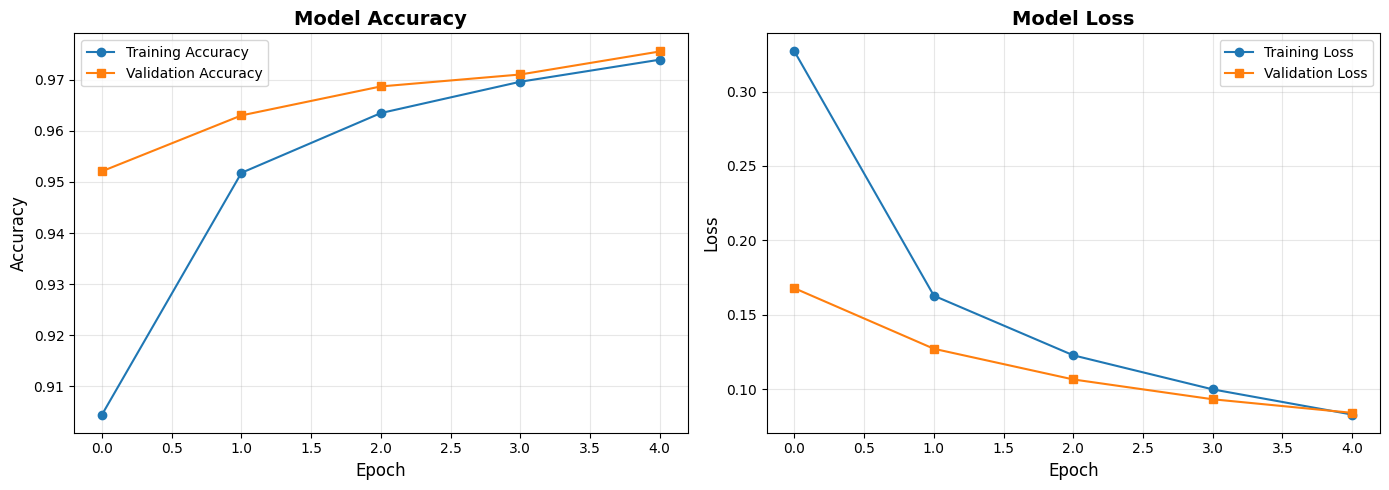

In [8]:
# Vẽ biểu đồ Accuracy
plt.figure(figsize=(14, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## i) Dự đoán phân lớp cho tập test

In [9]:
# Dự đoán cho tập test
y_pred_prob = model.predict(test_images)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Đã dự đoán xong cho tập test!")
print(f"Số lượng mẫu dự đoán: {len(y_pred)}")
print(f"\n5 dự đoán đầu tiên: {y_pred[:5]}")
print(f"5 nhãn thực tế đầu tiên: {test_labels[:5]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Đã dự đoán xong cho tập test!
Số lượng mẫu dự đoán: 10000

5 dự đoán đầu tiên: [7 2 1 0 4]
5 nhãn thực tế đầu tiên: [7 2 1 0 4]


## j) Tính và in ra Accuracy của mô hình trên tập test

In [10]:
# Tính Accuracy
test_accuracy = accuracy_score(test_labels, y_pred)

print("="*60)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("="*60)
print(f"\nAccuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

Accuracy: 0.9745 (97.45%)


## k) Tính và in ra Precision, Recall, F1-score

In [11]:
# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, y_pred, target_names=[str(i) for i in range(10)]))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## l) Hiển thị confusion matrix bằng heat map

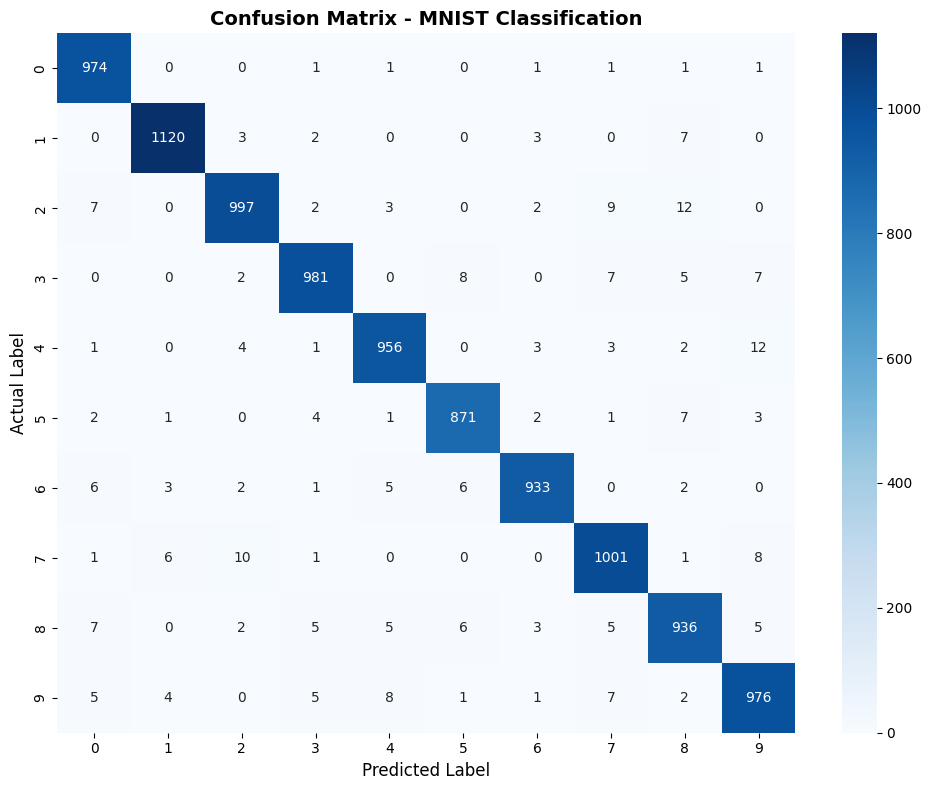

In [12]:
# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), 
            yticklabels=range(10))
plt.title('Confusion Matrix - MNIST Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## m) In ra kết quả phân lớp của 5 ảnh đầu tiên trong tập test

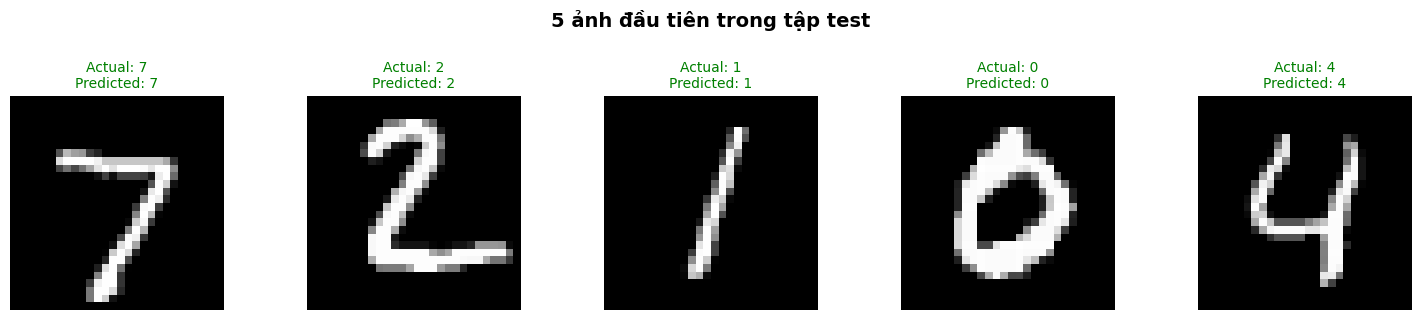


Chi tiết 5 ảnh đầu tiên:
Ảnh 1: Nhãn thực tế = 7, Dự đoán = 7, Độ tin cậy = 99.99% - ✓ ĐÚNG
Ảnh 2: Nhãn thực tế = 2, Dự đoán = 2, Độ tin cậy = 99.99% - ✓ ĐÚNG
Ảnh 3: Nhãn thực tế = 1, Dự đoán = 1, Độ tin cậy = 99.84% - ✓ ĐÚNG
Ảnh 4: Nhãn thực tế = 0, Dự đoán = 0, Độ tin cậy = 100.00% - ✓ ĐÚNG
Ảnh 5: Nhãn thực tế = 4, Dự đoán = 4, Độ tin cậy = 99.72% - ✓ ĐÚNG


In [13]:
# Hiển thị 5 ảnh đầu tiên và kết quả phân lớp
plt.figure(figsize=(15, 3))

for image_index in range(5):
    # Lấy ảnh từ tập test
    image = np.expand_dims(test_images[image_index], axis=0)
    
    # Dự đoán
    prediction_prob = model.predict(image, verbose=0)
    prediction = np.argmax(prediction_prob)
    
    # Hiển thị ảnh
    plt.subplot(1, 5, image_index + 1)
    plt.imshow(test_images[image_index], cmap='gray')
    plt.title(f'Actual: {test_labels[image_index]}\nPredicted: {prediction}', 
              fontsize=10,
              color='green' if prediction == test_labels[image_index] else 'red')
    plt.axis('off')

plt.suptitle('5 ảnh đầu tiên trong tập test', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# In ra chi tiết
print("\nChi tiết 5 ảnh đầu tiên:")
print("="*50)
for i in range(5):
    image = np.expand_dims(test_images[i], axis=0)
    prediction_prob = model.predict(image, verbose=0)
    prediction = np.argmax(prediction_prob)
    confidence = np.max(prediction_prob) * 100
    
    status = "✓ ĐÚNG" if prediction == test_labels[i] else "✗ SAI"
    print(f"Ảnh {i+1}: Nhãn thực tế = {test_labels[i]}, "
          f"Dự đoán = {prediction}, "
          f"Độ tin cậy = {confidence:.2f}% - {status}")

## n) In ra 5 kết quả đầu tiên phân lớp sai so với nhãn thực tế

Tổng số ảnh phân lớp sai: 255
Tỷ lệ phân lớp sai: 2.55%


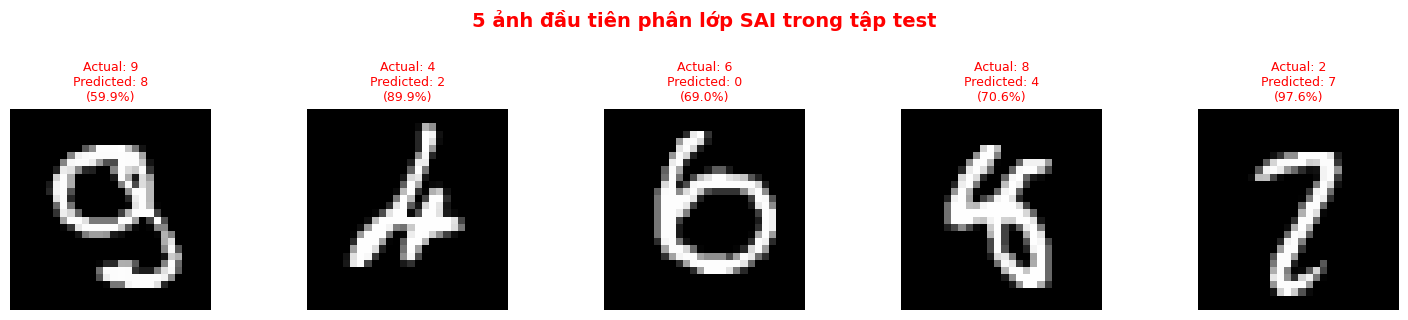


CHI TIẾT 5 ẢNH PHÂN LỚP SAI ĐẦU TIÊN

Ảnh sai thứ 1 (Index: 151):
  - Nhãn thực tế: 9
  - Dự đoán: 8
  - Độ tin cậy: 59.95%
  - Xác suất cho nhãn thực tế: 36.36%

Ảnh sai thứ 2 (Index: 247):
  - Nhãn thực tế: 4
  - Dự đoán: 2
  - Độ tin cậy: 89.92%
  - Xác suất cho nhãn thực tế: 1.16%

Ảnh sai thứ 3 (Index: 259):
  - Nhãn thực tế: 6
  - Dự đoán: 0
  - Độ tin cậy: 69.03%
  - Xác suất cho nhãn thực tế: 30.12%

Ảnh sai thứ 4 (Index: 290):
  - Nhãn thực tế: 8
  - Dự đoán: 4
  - Độ tin cậy: 70.62%
  - Xác suất cho nhãn thực tế: 26.30%

Ảnh sai thứ 5 (Index: 321):
  - Nhãn thực tế: 2
  - Dự đoán: 7
  - Độ tin cậy: 97.56%
  - Xác suất cho nhãn thực tế: 1.50%


In [14]:
# Tìm các chỉ số phân lớp sai
misclassified_indices = np.where(y_pred != test_labels)[0]

print(f"Tổng số ảnh phân lớp sai: {len(misclassified_indices)}")
print(f"Tỷ lệ phân lớp sai: {len(misclassified_indices)/len(test_labels)*100:.2f}%")

# Hiển thị 5 ảnh đầu tiên phân lớp sai
if len(misclassified_indices) >= 5:
    plt.figure(figsize=(15, 3))
    
    for i, idx in enumerate(misclassified_indices[:5]):
        # Lấy ảnh từ tập test
        image = np.expand_dims(test_images[idx], axis=0)
        
        # Dự đoán
        prediction_prob = model.predict(image, verbose=0)
        prediction = np.argmax(prediction_prob)
        confidence = np.max(prediction_prob) * 100
        
        # Hiển thị ảnh
        plt.subplot(1, 5, i + 1)
        plt.imshow(test_images[idx], cmap='gray')
        plt.title(f'Actual: {test_labels[idx]}\nPredicted: {prediction}\n({confidence:.1f}%)', 
                  fontsize=9, color='red')
        plt.axis('off')
    
    plt.suptitle('5 ảnh đầu tiên phân lớp SAI trong tập test', 
                 fontsize=14, fontweight='bold', y=1.05, color='red')
    plt.tight_layout()
    plt.show()
    
    # In ra chi tiết
    print("\n" + "="*70)
    print("CHI TIẾT 5 ẢNH PHÂN LỚP SAI ĐẦU TIÊN")
    print("="*70)
    for i, idx in enumerate(misclassified_indices[:5]):
        image = np.expand_dims(test_images[idx], axis=0)
        prediction_prob = model.predict(image, verbose=0)
        prediction = np.argmax(prediction_prob)
        confidence = np.max(prediction_prob) * 100
        
        print(f"\nẢnh sai thứ {i+1} (Index: {idx}):")
        print(f"  - Nhãn thực tế: {test_labels[idx]}")
        print(f"  - Dự đoán: {prediction}")
        print(f"  - Độ tin cậy: {confidence:.2f}%")
        print(f"  - Xác suất cho nhãn thực tế: {prediction_prob[0][test_labels[idx]]*100:.2f}%")
else:
    print("\nKhông đủ 5 ảnh phân lớp sai để hiển thị!")